# 2019 Dataset - EDA

In [2]:
import pandas as pd
import os

data_folder = os.path.join("../..", "data")
csv_name = "On-street_Car_Parking_Sensor_Data_-_2019.csv"
csv_path = os.path.join(data_folder, csv_name)

df_100k = pd.read_csv(csv_path, nrows=100000, low_memory=False) # low_memory=False to avoid dtype inference issues with mixed types
df_100k.info()
display(df_100k.head())

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   DeviceId          100000 non-null  int64  
 1   ArrivalTime       100000 non-null  str    
 2   DepartureTime     100000 non-null  str    
 3   DurationMinutes   100000 non-null  str    
 4   StreetMarker      100000 non-null  str    
 5   SignPlateID       65361 non-null   float64
 6   Sign              65361 non-null   str    
 7   AreaName          100000 non-null  str    
 8   StreetId          100000 non-null  int64  
 9   StreetName        100000 non-null  str    
 10  BetweenStreet1ID  100000 non-null  int64  
 11  BetweenStreet1    100000 non-null  str    
 12  BetweenStreet2ID  100000 non-null  int64  
 13  BetweenStreet2    100000 non-null  str    
 14  SideOfStreet      100000 non-null  int64  
 15  SideOfStreetCode  100000 non-null  str    
 16  SideName          100000 non-nul

,DeviceId,ArrivalTime,DepartureTime,DurationMinutes,StreetMarker,SignPlateID,Sign,AreaName,StreetId,StreetName,BetweenStreet1ID,BetweenStreet1,BetweenStreet2ID,BetweenStreet2,SideOfStreet,SideOfStreetCode,SideName,BayId,InViolation,VehiclePresent
0,23915,11/03/2019 03:00:56 AM,11/03/2019 03:07:26 AM,7,2374N,NaN,NaN,Windsor,123,BOURKE STREET,1221,RUSSELL STREET,647,EXHIBITION STREET,3,N,North,1753,False,False
1,23914,04/16/2019 02:14:47 PM,04/16/2019 02:15:23 PM,1,1896N,287.0,1P MTR M-SAT 7:30-18:30,Twin Towers,528,COLLINS STREET,647,EXHIBITION STREET,1288,SPRING STREET,3,N,North,1532,False,False
2,23913,09/29/2019 01:08:22 AM,09/29/2019 01:31:41 AM,23,1581S,NaN,NaN,Banks,670,FLINDERS STREET,1171,QUEEN STREET,627,ELIZABETH STREET,4,S,South,1399,False,False
3,23915,06/05/2019 06:59:17 PM,06/05/2019 06:59:24 PM,0,2374N,508.0,2P MTR M-SAT 18.30 - 20.30,Windsor,123,BOURKE STREET,1221,RUSSELL STREET,647,EXHIBITION STREET,3,N,North,1753,False,False
4,23915,04/01/2019 07:03:41 AM,04/01/2019 07:14:12 AM,11,2374N,NaN,NaN,Windsor,123,BOURKE STREET,1221,RUSSELL STREET,647,EXHIBITION STREET,3,N,North,1753,False,True


### Missing values

In [3]:
# Check for missing values
missing_values = df_100k.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
DeviceId                0
ArrivalTime             0
DepartureTime           0
DurationMinutes         0
StreetMarker            0
SignPlateID         34639
Sign                34639
AreaName                0
StreetId                0
StreetName              0
BetweenStreet1ID        0
BetweenStreet1          0
BetweenStreet2ID        0
BetweenStreet2          0
SideOfStreet            0
SideOfStreetCode        0
SideName                0
BayId                   0
InViolation             0
VehiclePresent          0
dtype: int64


### Unique values

In [4]:
# See unique values
unique_values = df_100k.nunique()
print("\nUnique values in each column:")
print(unique_values)


Unique values in each column:
DeviceId               85
ArrivalTime         91490
DepartureTime       91564
DurationMinutes       709
StreetMarker           85
SignPlateID            49
Sign                   49
AreaName               30
StreetId               33
StreetName             33
BetweenStreet1ID       32
BetweenStreet1         32
BetweenStreet2ID       33
BetweenStreet2         33
SideOfStreet            5
SideOfStreetCode        5
SideName                5
BayId                  85
InViolation             2
VehiclePresent          2
dtype: int64


### Conversión de DurationMinutes: str --> float

In [5]:
# Make a copy of original df to save modifications
df_100k_mod = df_100k.copy()

# Inspect values in DurationMinutes column, as they are str type and they should probably be int or float
duration_numeric = pd.to_numeric(df_100k_mod['DurationMinutes'], errors='coerce')
problematic = df_100k_mod[duration_numeric.isna()]['DurationMinutes'].unique()

print(f"Valores no numéricos únicos: {len(problematic)}")
print(f"Detalle de los valores no numéricos:")
for i, val in enumerate(problematic[:30]):
    print(f"  {i+1}. Valor: '{val}'")
# Values contain commas, as European style for decimals

valid = df_100k_mod[~duration_numeric.isna()]['DurationMinutes'].unique()
print(f"\nValores válidos numéricos únicos: {len(valid)}")
print(f"Detalle de los primeros 10 valores numéricos:")
for i, val in enumerate(valid[:10]):
    numeric_val = pd.to_numeric(val)
    print(f"  {i+1}. Valor: '{val}'")

# Replace commas with dots and convert to float
df_100k_mod['DurationMinutes'] = df_100k_mod['DurationMinutes'].str.replace(',', '.').astype(float)
print("\nEstadísticas después de la conversión:")
print(f"Total de filas: {len(df_100k_mod)}")
print(f"Valores válidos: {df_100k_mod['DurationMinutes'].notna().sum()}, tipo: {df_100k_mod['DurationMinutes'].dtype}")
print(f"Valores inválidos (NaN): {df_100k_mod['DurationMinutes'].isna().sum()}")

Valores no numéricos únicos: 13
Detalle de los valores no numéricos:
  1. Valor: '1,440'
  2. Valor: '1,111'
  3. Valor: '1,334'
  4. Valor: '1,314'
  5. Valor: '1,166'
  6. Valor: '1,094'
  7. Valor: '1,139'
  8. Valor: '1,303'
  9. Valor: '1,275'
  10. Valor: '1,045'
  11. Valor: '1,079'
  12. Valor: '1,012'
  13. Valor: '1,001'

Valores válidos numéricos únicos: 696
Detalle de los primeros 10 valores numéricos:
  1. Valor: '7'
  2. Valor: '1'
  3. Valor: '23'
  4. Valor: '0'
  5. Valor: '11'
  6. Valor: '9'
  7. Valor: '113'
  8. Valor: '26'
  9. Valor: '6'
  10. Valor: '3'

Estadísticas después de la conversión:
Total de filas: 100000
Valores válidos: 100000, tipo: float64
Valores inválidos (NaN): 0


### Conversión de variables temporales: str --> dateTime

In [6]:
# Conversión de variables temporales a formato dateTime 
df_100k_mod['ArrivalTime'] = pd.to_datetime(df_100k_mod['ArrivalTime'])
df_100k_mod['DepartureTime'] = pd.to_datetime(df_100k_mod['DepartureTime'])
print(df_100k_mod[['ArrivalTime', 'DepartureTime']].describe())

                      ArrivalTime               DepartureTime
count                      100000                      100000
mean   2019-07-14 20:05:30.078670  2019-07-14 20:54:15.603470
min           2019-01-01 00:00:00         2019-01-01 00:15:04
25%    2019-04-26 13:29:46.500000  2019-04-26 13:47:23.500000
50%    2019-07-20 21:22:41.500000  2019-07-20 21:45:27.500000
75%    2019-10-06 18:30:09.250000  2019-10-06 19:20:16.750000
max           2019-12-31 21:53:40         2019-12-31 22:55:06


### Inspeccionar matches entre variables

In [7]:
# Identify matches between SideOfStreet and SideOfStreetCode
matches=[]
for fila in df_100k.itertuples():
    SideOfStreet = fila.SideOfStreet
    SideOfStreetCode = fila.SideOfStreetCode
    if not any(m[0] == SideOfStreet for m in matches):
        matches.append((SideOfStreet, SideOfStreetCode))
        print(f"New match found: SideOfStreet {SideOfStreet} matches SideOfStreetCode {SideOfStreetCode}")
    else:
        if (SideOfStreet, SideOfStreetCode) not in matches:
            print(f"Mismatch found: SideOfStreet {SideOfStreet} does not match SideOfStreetCode {SideOfStreetCode}")

unique_side_of_streets = df_100k['SideOfStreet'].unique()
unique_side_of_street_codes = df_100k['SideOfStreetCode'].unique()
print(f"Unique SideOfStreets: {len(unique_side_of_streets)}")
print(f"Unique SideOfStreetCodes: {len(unique_side_of_street_codes)}")

New match found: SideOfStreet 3 matches SideOfStreetCode N
New match found: SideOfStreet 4 matches SideOfStreetCode S
New match found: SideOfStreet 5 matches SideOfStreetCode W
New match found: SideOfStreet 1 matches SideOfStreetCode C
New match found: SideOfStreet 2 matches SideOfStreetCode E
Unique SideOfStreets: 5
Unique SideOfStreetCodes: 5


In [8]:
# Identify matches between DeviceId and StreetMarker 
matches=[]
for fila in df_100k.itertuples():
    device_id = fila.DeviceId
    street_marker = fila.StreetMarker
    if not any(m[0] == device_id for m in matches):
        matches.append((device_id, street_marker))
        print(f"New match found: DeviceId {device_id} matches StreetMarker {street_marker}")
    else:
        if (device_id, street_marker) not in matches:
            print(f"Mismatch found: DeviceId {device_id} does not match StreetMarker {street_marker}")

unique_device_ids = df_100k['DeviceId'].unique()
unique_street_markers = df_100k['StreetMarker'].unique()
print(f"Unique DeviceIds: {len(unique_device_ids)}")
print(f"Unique StreetMarkers: {len(unique_street_markers)}")

New match found: DeviceId 23915 matches StreetMarker 2374N
New match found: DeviceId 23914 matches StreetMarker 1896N
New match found: DeviceId 23913 matches StreetMarker 1581S
New match found: DeviceId 23916 matches StreetMarker 2334N
New match found: DeviceId 27446 matches StreetMarker 6571S
New match found: DeviceId 27164 matches StreetMarker 1291W
New match found: DeviceId 25982 matches StreetMarker C726
New match found: DeviceId 25433 matches StreetMarker 15092E
New match found: DeviceId 27596 matches StreetMarker 767Wa
New match found: DeviceId 26585 matches StreetMarker 12811S
New match found: DeviceId 26445 matches StreetMarker 13345W
New match found: DeviceId 26632 matches StreetMarker 4466E
New match found: DeviceId 25520 matches StreetMarker 15182N
New match found: DeviceId 25724 matches StreetMarker 3958N
New match found: DeviceId 26754 matches StreetMarker 3668N
New match found: DeviceId 23944 matches StreetMarker 3166N
New match found: DeviceId 23941 matches StreetMarker 

### Gráficas ilustrativas

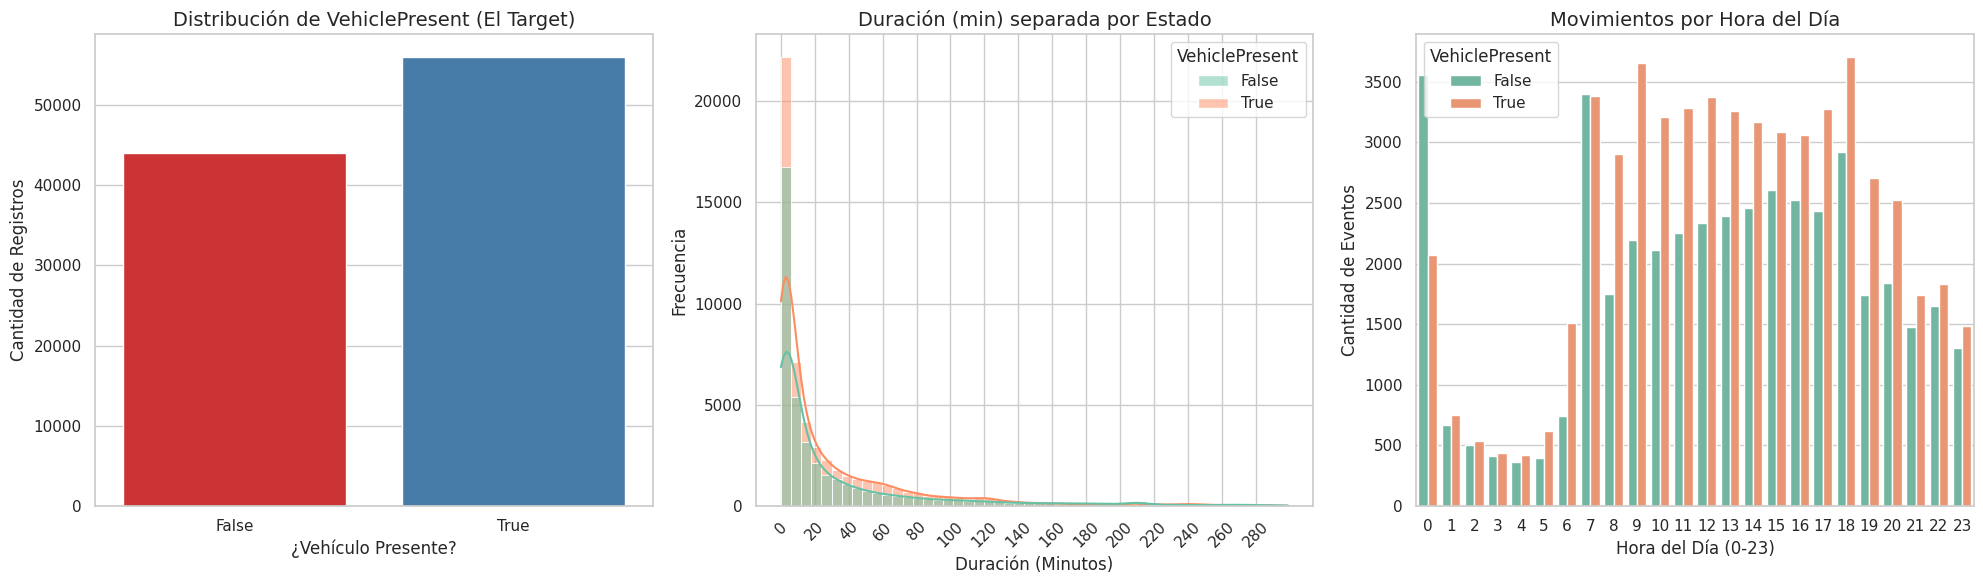

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extraer la 'Hora' de ArrivalTime para analizar el comportamiento por hora del día
df_100k_mod['Hour'] = df_100k_mod['ArrivalTime'].dt.hour

# Configuramos el estilo visual de las gráficas
sns.set_theme(style="whitegrid")
# Creamos una figura grande para poner 3 gráficas (1 fila, 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ===================================================================
# GRÁFICA 1: Distribución del Target (VehiclePresent)
# ===================================================================
# ¿Hay más tiempo de aparcamiento ocupado o vacío?
sns.countplot(data=df_100k_mod, x='VehiclePresent', hue='VehiclePresent', palette='Set1', ax=axes[0], legend=False)
axes[0].set_title('Distribución de VehiclePresent (El Target)', fontsize=14)
axes[0].set_xlabel('¿Vehículo Presente?', fontsize=12)
axes[0].set_ylabel('Cantidad de Registros', fontsize=12)

# ===================================================================
# GRÁFICA 2: Distribución de DurationMinutes separada por el Target
# ===================================================================
# ¿Cuánto tiempo duran los coches aparcados vs el tiempo que la plaza está vacía?
# OJO: Recortamos los datos a duraciones menores de 300 minutos (5 horas)
# porque a veces hay coches aparcados 3 días por error y rompen la gráfica.
mask_duracion = df_100k_mod['DurationMinutes'] < 300
sns.histplot(data=df_100k_mod[mask_duracion], 
             x='DurationMinutes', 
             hue='VehiclePresent', 
             bins=50, 
             kde=True, 
             palette='Set2', 
             ax=axes[1])
axes[1].set_xticks(range(0, 300, 20))
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title('Duración (min) separada por Estado', fontsize=14)
axes[1].set_xlabel('Duración (Minutos)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)

# ===================================================================
# GRÁFICA 3: Comportamiento por Hora del Día
# ===================================================================
# ¿A qué hora hay más movimientos de coches llegando o yéndose?
sns.countplot(data=df_100k_mod, x='Hour', hue='VehiclePresent', palette='Set2', ax=axes[2])
axes[2].set_title('Movimientos por Hora del Día', fontsize=14)
axes[2].set_xlabel('Hora del Día (0-23)', fontsize=12)
axes[2].set_ylabel('Cantidad de Eventos', fontsize=12)

# Ajustamos el espaciado y mostramos la "obra de arte"
plt.tight_layout()
plt.show()